In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json

# Filtering

**No need to run if already have the processed directory** <br> Just the last two

## Business:

In [42]:
business=pd.read_json(r'data\data_raw\yelp_academic_dataset_business.json',lines=True)

#we want to create a subset, but first let's explore the data a bit:
unique_states=business['state'].unique()
print(f'Unique states: {", ".join(unique_states)}')

city_counts=business['city'].value_counts()
most_common_city=city_counts.idxmax()
most_common_city_count=city_counts.max()
most_common_city_state=business[business['city']==most_common_city]['state'].iloc[0]
print(f'Most common city: {most_common_city} ({most_common_city_state}) with {most_common_city_count} businesses')



Unique states: CA, MO, AZ, PA, TN, FL, IN, LA, AB, NV, ID, DE, IL, NJ, NC, CO, WA, HI, UT, TX, MT, MI, SD, XMS, MA, VI, VT
Most common city: Philadelphia (PA) with 14569 businesses


In [43]:
#print all cities of PA
pa_cities=business[business['state']=='PA']['city'].unique()
print(f'Cities in PA: {", ".join(pa_cities)}')

#print cities that look similar to philadelphia:
philadelphia_cities=business[business['city'].str.contains('philadelphia', case=False)]['city'].unique()
print(f'Cities similar to Philadelphia: {", ".join(philadelphia_cities)}')


Cities in PA: Philadelphia, Green Lane, Newtown, Paoli, Ardmore, Exton, Bala Cynwyd, Springfield, Kennett Square, Plymouth Meeting, West Chester, Glenolden, Bensalem, Southampton, Chalfont, Willow Grove, Blue Bell, Norristown, Brookhaven, Haverford, Glenside, Levittown, Aston, Warrington, Wyncote, Havertown, Langhorne, King of Prussia, Jenkintown, Wayne, Berwyn, Delaware County, Doylestown, Downingtown, Warminster, Chester, Horsham, Valley Forge, Malvern, Lansdale, Villanova, Narberth, Bristol, Perkiomenville, Montgomeryville, Morrisville, North Wales, Upper Darby, Elkins Park, New Hope, Buckingham, Media, Conshohocken, Chadds Ford, Skippack, Bryn Mawr, Feasterville, Pottstown, Spring City, Ambler, Hatfield, King Of Prussia, Yardley, St. Davids, Primos, Huntingdon Valley, Collingdale, Fort Washington, Silverdale, Limerick, Lionville, Oreland, Prospect Park, Fountainville, Collegeville, Royersford, Bridgeport, Roslyn, Huntingdon Valley PA, Washington Crossing, Drexel Hill, Folsom, Harle

Number of businesses in Philadelphia, PA: 14584


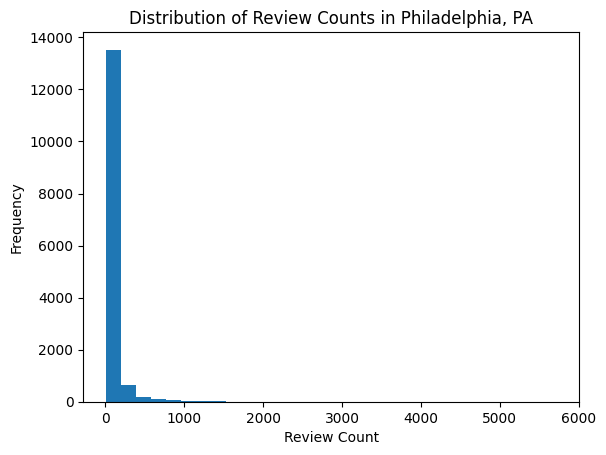

In [41]:
#chart of review counts in philadelphia, PA
import matplotlib.pyplot as plt
business['city_clean'] = business['city'].str.lower().str.strip()
business_filtered = business[ # we may use lat and lon in the future, but for now let's just filter by city and state
    (business['state'] == 'PA') &
    (business['city_clean'].str.contains('philadelphia'))
]
print(f'Number of businesses in Philadelphia, PA: {len(business_filtered)}')
plt.hist(business_filtered['review_count'], bins=30)
plt.xlabel('Review Count')
plt.ylabel('Frequency')
plt.title('Distribution of Review Counts in Philadelphia, PA')
plt.show()

In [54]:
business['state_clean'] = business['state'].str.lower().str.strip()
business['city_clean'] = business['city'].str.lower().str.strip()

business_filtered = business[
    (business['state_clean'] == 'pa') &
    (business['city_clean'].str.contains('philadelphia'))
]

print(f'Number of businesses in Philadelphia, PA: {len(business_filtered)}')

business_filtered = business_filtered[business_filtered['review_count'] > 10]
print(f'Number of businesses in Philadelphia, PA with more than 10 reviews: {len(business_filtered)}')
print(f'List of cities in the filtered dataset: {", ".join(business_filtered["city"].unique())}')
business_filtered.to_json(r'data\filtered_data\business_philadelphia_pa.json', orient='records', lines=True)

Number of businesses in Philadelphia, PA: 14584
Number of businesses in Philadelphia, PA with more than 10 reviews: 9930
List of cities in the filtered dataset: Philadelphia, Southwest Philadelphia, PHILADELPHIA, philadelphia, Philadelphia (Northeast Philly), Philadelphia 


In [55]:
business_filtered=pd.read_json(r'data\filtered_data\business_philadelphia_pa.json', lines=True)
print(f'Number of businesses in the filtered dataset: {len(business_filtered)}')

Number of businesses in the filtered dataset: 9930


In [67]:
#checke for nulls in the filtered dataset
print(f'Null values in the filtered dataset:\n{business_filtered.isnull().sum()}')

Null values in the filtered dataset:
business_id        0
name               0
address            0
city               0
state              0
postal_code        0
latitude           0
longitude          0
stars              0
review_count       0
is_open            0
attributes       426
categories         0
hours           1304
city_clean         0
state_clean        0
dtype: int64


In [69]:
business_filtered["attributes"]

0       {'RestaurantsDelivery': 'False', 'OutdoorSeati...
1       {'RestaurantsReservations': 'True', 'Restauran...
2       {'NoiseLevel': 'u'quiet'', 'GoodForMeal': '{'d...
3       {'Smoking': 'u'no'', 'NoiseLevel': 'u'average'...
4       {'RestaurantsReservations': 'False', 'Caters':...
                              ...                        
9925    {'NoiseLevel': 'u'average'', 'RestaurantsTakeO...
9926    {'RestaurantsGoodForGroups': 'True', 'BikePark...
9927    {'BusinessAcceptsCreditCards': 'True', 'Wheelc...
9928    {'ByAppointmentOnly': 'True', 'GoodForKids': '...
9929    {'WheelchairAccessible': 'False', 'Restaurants...
Name: attributes, Length: 9930, dtype: object

In [70]:
business_filtered["hours"]

0       {'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...
1       {'Tuesday': '13:30-22:0', 'Wednesday': '13:30-...
2       {'Monday': '11:30-20:30', 'Tuesday': '11:30-20...
3       {'Monday': '16:0-0:0', 'Tuesday': '16:0-0:0', ...
4       {'Tuesday': '17:0-21:30', 'Wednesday': '17:0-1...
                              ...                        
9925    {'Monday': '10:0-21:0', 'Tuesday': '10:0-21:0'...
9926    {'Monday': '9:0-19:30', 'Tuesday': '9:0-19:30'...
9927    {'Monday': '9:0-22:0', 'Tuesday': '9:0-22:0', ...
9928    {'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...
9929    {'Monday': '11:0-22:0', 'Tuesday': '11:0-22:0'...
Name: hours, Length: 9930, dtype: object

## Reviews

In [56]:
#now we filter the users and reviews datasets to only include those related to the businesses in our filtered dataset, to reduce the size of the data we will be working with:
selected_business_ids=set(business_filtered['business_id'].unique())
with open(r'data\data_raw\yelp_academic_dataset_review.json', 'r', encoding='utf-8') as f_in, \
    open(r'data\filtered_data\review_philadelphia_pa.json', 'w', encoding='utf-8') as f_out:
    for line in f_in:
        review = json.loads(line)
        if review['business_id'] in selected_business_ids:
            f_out.write(json.dumps(review) + '\n')


In [57]:
review_filtered=pd.read_json(r'data\filtered_data\review_philadelphia_pa.json', lines=True)
print(f'Number of reviews in the filtered dataset: {len(review_filtered)}')

Number of reviews in the filtered dataset: 934295


In [66]:
#print summary number of reviews per business
reviews_per_business_summary = review_filtered['business_id'].value_counts().describe()
print(f'Summary of number of reviews per business:\n{reviews_per_business_summary}')

Summary of number of reviews per business:
count    9930.000000
mean       94.088117
std       199.782813
min        11.000000
25%        19.000000
50%        36.000000
75%        87.000000
max      5778.000000
Name: count, dtype: float64


In [71]:
#check for nulls in the filtered reviews dataset
print(f'Null values in the filtered reviews dataset:\n{review_filtered.isnull().sum()}')

Null values in the filtered reviews dataset:
review_id      0
user_id        0
business_id    0
stars          0
useful         0
funny          0
cool           0
text           0
date           0
dtype: int64


## Usuarios

In [63]:
selected_users=set(review_filtered['user_id'].unique())
with open(r'data\data_raw\yelp_academic_dataset_user.json', 'r', encoding='utf-8') as f_in, \
    open(r'data\filtered_data\user_philadelphia_pa.json', 'w', encoding='utf-8') as f_out:
    for line in f_in:
        user = json.loads(line)
        if user['user_id'] in selected_users and user['review_count'] > 5: # we also filter users with more than 5 reviews to focus on more active users
            f_out.write(json.dumps(user) + '\n')


In [37]:
users_filtered=pd.read_json(r'data\filtered_data\user_philadelphia_pa.json', lines=True)
print(f'Number of users in the filtered dataset: {len(users_filtered)}')

Number of users in the filtered dataset: 279989


In [72]:
#check for nulls in the filtered reviews dataset
print(f'Null values in the filtered reviews dataset:\n{review_filtered.isnull().sum()}')

Null values in the filtered reviews dataset:
review_id      0
user_id        0
business_id    0
stars          0
useful         0
funny          0
cool           0
text           0
date           0
dtype: int64


## Checkin

In [59]:
with open(r'data\data_raw\yelp_academic_dataset_checkin.json', 'r', encoding='utf-8') as f_in, \
    open(r'data\filtered_data\checkin_philadelphia_pa.json', 'w', encoding='utf-8') as f_out:
    for line in f_in:
        checkin = json.loads(line)
        if checkin['business_id'] in selected_business_ids:
            f_out.write(json.dumps(checkin) + '\n')

In [60]:
checkin_filtered=pd.read_json(r'data\filtered_data\checkin_philadelphia_pa.json', lines=True)
print(f'Number of check-ins in the filtered dataset: {len(checkin_filtered)}')

Number of check-ins in the filtered dataset: 9419


In [73]:
#check for nulls in the filtered reviews dataset
print(f'Null values in the filtered reviews dataset:\n{review_filtered.isnull().sum()}')

Null values in the filtered reviews dataset:
review_id      0
user_id        0
business_id    0
stars          0
useful         0
funny          0
cool           0
text           0
date           0
dtype: int64


## Tips

In [61]:
with open(r'data\data_raw\yelp_academic_dataset_tip.json', 'r', encoding='utf-8') as f_in, \
    open(r'data\filtered_data\tip_philadelphia_pa.json', 'w', encoding='utf-8') as f_out:
    for line in f_in:
        tip = json.loads(line)
        if tip['business_id'] in selected_business_ids:
            f_out.write(json.dumps(tip) + '\n')

In [62]:
tip_filtered=pd.read_json(r'data\filtered_data\tip_philadelphia_pa.json', lines=True)
print(f'Number of tips in the filtered dataset: {len(tip_filtered)}')

Number of tips in the filtered dataset: 114179


In [74]:
#check for nulls in the filtered reviews dataset
print(f'Null values in the filtered reviews dataset:\n{review_filtered.isnull().sum()}')

Null values in the filtered reviews dataset:
review_id      0
user_id        0
business_id    0
stars          0
useful         0
funny          0
cool           0
text           0
date           0
dtype: int64


# New table

In [75]:
business=pd.read_json(r'data\filtered_data\business_philadelphia_pa.json',lines=True)
review=pd.read_json(r'data\filtered_data\review_philadelphia_pa.json',lines=True)
user=pd.read_json(r'data\filtered_data\user_philadelphia_pa.json',lines=True)
checkin=pd.read_json(r'data\filtered_data\checkin_philadelphia_pa.json',lines=True)
tip=pd.read_json(r'data\filtered_data\tip_philadelphia_pa.json',lines=True)

In [76]:
print(f'review dataset columns: {", ".join(review.columns)}')

review dataset columns: review_id, user_id, business_id, stars, useful, funny, cool, text, date


In [77]:
print(f'Business dataset columns: {", ".join(business.columns)}')

Business dataset columns: business_id, name, address, city, state, postal_code, latitude, longitude, stars, review_count, is_open, attributes, categories, hours, city_clean, state_clean


In [78]:
print(f'user dataset columns: {", ".join(user.columns)}')

user dataset columns: user_id, name, review_count, yelping_since, useful, funny, cool, elite, friends, fans, average_stars, compliment_hot, compliment_more, compliment_profile, compliment_cute, compliment_list, compliment_note, compliment_plain, compliment_cool, compliment_funny, compliment_writer, compliment_photos


In [139]:
reviews_enriched=review.merge(business[['business_id', 'name', 'categories','stars','review_count']], on='business_id', how='left',suffixes=('_review', '_business'))
reviews_enriched=reviews_enriched.merge(user[['user_id', 'review_count','average_stars']], on='user_id', how='left', suffixes=('_business', '_user'))

In [140]:
print(f'Number of rows in the enriched reviews dataset: {len(reviews_enriched)}')
print(f'Columns in the enriched reviews dataset: {", ".join(reviews_enriched.columns)}')

Number of rows in the enriched reviews dataset: 934295
Columns in the enriched reviews dataset: review_id, user_id, business_id, stars_review, useful, funny, cool, text, date, name, categories, stars_business, review_count_business, review_count_user, average_stars


In [141]:
#rename columns from _review, _business and _user to more descriptive names
reviews_enriched.rename(columns={'review_count_business': 'business_review_count', 'review_count_user': 'user_review_count',
                                'stars_review': 'review_stars', 'useful': 'review_useful', 'funny': 'review_funny', 'cool': 'review_cool',
                                 'average_stars':'user_average_stars','name':'business_name','stars_business':'business_stars'}, inplace=True)

In [142]:
print(f'Columns in the enriched reviews dataset: {", ".join(reviews_enriched.columns)}')

Columns in the enriched reviews dataset: review_id, user_id, business_id, review_stars, review_useful, review_funny, review_cool, text, date, business_name, categories, business_stars, business_review_count, user_review_count, user_average_stars


In [143]:
print(f'Number of nulls: {reviews_enriched.isnull().sum()}')

Number of nulls: review_id                     0
user_id                       0
business_id                   0
review_stars                  0
review_useful                 0
review_funny                  0
review_cool                   0
text                          0
date                          0
business_name                 0
categories                    0
business_stars                0
business_review_count         0
user_review_count        158340
user_average_stars       158340
dtype: int64


In [144]:
print(f'Number of duplicated: {reviews_enriched.duplicated().sum()}')

Number of duplicated: 0


In [149]:
reviews_enriched.dropna(inplace=True)
print(f'Number of nulls after dropping: {reviews_enriched.isnull().sum()}')
print(f'Number of total rows after dropping nulls: {len(reviews_enriched)}')
print(f'Number of duplicated after dropping nulls: {reviews_enriched.duplicated().sum()}')

Number of nulls after dropping: review_id                0
user_id                  0
business_id              0
review_stars             0
review_useful            0
review_funny             0
review_cool              0
text                     0
date                     0
business_name            0
categories               0
business_stars           0
business_review_count    0
user_review_count        0
user_average_stars       0
dtype: int64
Number of total rows after dropping nulls: 775955
Number of duplicated after dropping nulls: 0


In [146]:
reviews_enriched.head(5)

,review_id,user_id,business_id,review_stars,review_useful,review_funny,review_cool,text,date,business_name,categories,business_stars,business_review_count,user_review_count,user_average_stars
0,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18,Body Cycle Spinning Studio,"Active Life, Cycling Classes, Trainers, Gyms, ...",5.0,144,10.0,4.30
1,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,Zaika,"Halal, Pakistani, Restaurants, Indian",4.0,181,9.0,4.78
3,8JFGBuHMoiNDyfcxuWNtrA,smOvOajNG0lS4Pq7d8g4JQ,RZtGWDLCAtuipwaZ-UfjmQ,4,0,0,0,Good food--loved the gnocchi with marinara\nth...,2009-10-14 19:57:14,LaScala's,"Pizza, Restaurants, Italian, Salad",3.5,367,176.0,3.46
5,Xs8Z8lmKkosqW5mw_sVAoA,IQsF3Rc6IgCzjVV9DE8KXg,eFvzHawVJofxSnD7TgbZtg,5,0,0,0,My absolute favorite cafe in the city. Their b...,2014-11-12 15:30:27,Good Karma Cafe,"Food, Cafes, Coffee & Tea, Restaurants",4.0,249,182.0,3.41
6,J-4NdnDZ0pUQaUEEwDI9KQ,vrKkXsozqqecF3CW4cGaVQ,rjuWz_AD3WfXJc03AhIO_w,5,2,2,2,I thoroughly enjoyed the show. Chill way to s...,2012-12-04 16:46:20,The N Crowd,"Performing Arts, Arts & Entertainment, Nightli...",4.5,90,120.0,4.44


In [148]:
reviews_enriched.describe()

,review_stars,review_useful,review_funny,review_cool,date,business_stars,business_review_count,user_review_count,user_average_stars
count,775955.000000,775955.000000,775955.000000,775955.000000,775955,775955.000000,775955.000000,775955.000000,775955.000000
mean,3.849371,1.388854,0.452842,0.658457,2015-09-15 09:25:15.237811,3.806519,535.764379,174.124333,3.813904
min,1.000000,0.000000,0.000000,0.000000,2005-02-16 04:06:26,1.000000,11.000000,6.000000,1.000000
25%,3.000000,0.000000,0.000000,0.000000,2013-03-28 20:18:20.500000,3.500000,90.000000,18.000000,3.540000
50%,4.000000,1.000000,0.000000,0.000000,2015-12-14 22:42:28,4.000000,246.000000,53.000000,3.870000
75%,5.000000,2.000000,0.000000,1.000000,2018-05-30 13:13:59,4.000000,610.000000,177.000000,4.170000
max,5.000000,224.000000,284.000000,192.000000,2022-01-19 19:26:37,5.000000,5721.000000,17473.000000,5.000000
std,1.286099,3.096577,1.824905,2.231888,NaN,0.650196,809.315266,405.477675,0.559594


In [156]:
#we save the filtered business in a new file, so we can load it later without having to filter it again.
reviews_enriched.to_parquet(r'data\processed\reviews_enriched_v1.parquet', index=False, engine='pyarrow')

In [3]:
reviews_enriched=pd.read_parquet(r'data\processed\reviews_enriched_v1.parquet', engine='pyarrow')
print(f'Number of rows in the enriched reviews dataset: {len(reviews_enriched)}')

Number of rows in the enriched reviews dataset: 775955


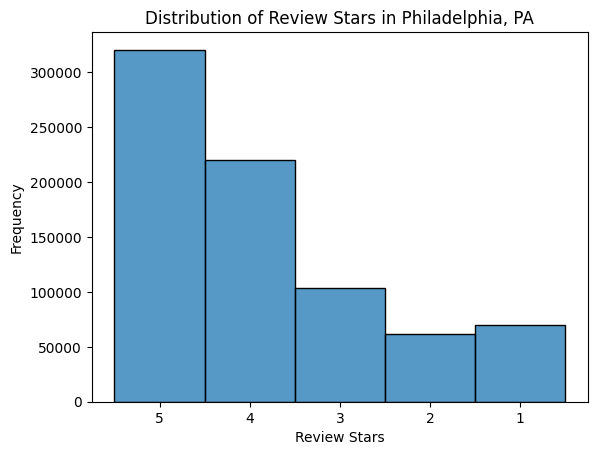

In [159]:
#plot the distribution of review stars
sns.histplot(reviews_enriched['review_stars'], bins=5, kde=False)
plt.xlabel('Review Stars')
plt.ylabel('Frequency')
plt.title('Distribution of Review Stars in Philadelphia, PA')
plt.show()

In [164]:
#visualize categories of businesses in the enriched reviews dataset
reviews_enriched['categories_list'] = reviews_enriched['categories'].str.split(', ')
all_categories = [category for sublist in reviews_enriched['categories_list'] for category in sublist]
category_counts = pd.Series(all_categories).value_counts()
print(f'Categories of businesses in the enriched reviews dataset:\n{category_counts}')
print(f' Total number of unique categories: {len(category_counts)}')

#search all that contain similar te xto to restaurants:
restaurant_categories = category_counts[category_counts.index.str.contains('restaurant', case=False)]
print(f'Categories related to restaurants:\n{restaurant_categories}')

Categories of businesses in the enriched reviews dataset:
Restaurants               581007
Food                      229457
Nightlife                 201078
Bars                      191201
American (New)            132686
                           ...  
Crane Services                 4
Medical Transportation         3
Tutoring Centers               3
Piano Services                 3
Digitizing Services            1
Name: count, Length: 943, dtype: int64
 Total number of unique categories: 943
Categories related to restaurants:
Restaurants           581007
Pop-Up Restaurants       224
Name: count, dtype: int64


In [165]:
reviews_enriched.columns

Index(['review_id', 'user_id', 'business_id', 'review_stars', 'review_useful',
       'review_funny', 'review_cool', 'text', 'date', 'business_name',
       'categories', 'business_stars', 'business_review_count',
       'user_review_count', 'user_average_stars', 'categories_list'],
      dtype='str')

In [ ]:
reviews_enriched['categories_list'] = reviews_enriched['categories'].str.split(', ')
all_categories = [category for sublist in reviews_enriched['categories_list'] for category in sublist]
category_counts = pd.Series(all_categories).value_counts()
category_counts

In [ ]:
reviews_enriched['categories_list'] 

In [ ]:
#date into datetime
reviews_enriched['date'] = pd.to_datetime(reviews_enriched['date'])

In [ ]:
reviews_enriched = reviews_enriched.astype({

    'review_id': 'string',
    'user_id': 'string',
    'business_id': 'string',
    
    'review_stars': 'float',
    'business_stars': 'float',
    'user_average_stars': 'float',
    
    'review_useful': 'float',
    'review_funny': 'float',
    'review_cool': 'float',
    'business_review_count': 'float',
    'user_review_count': 'float',
    
    'text': 'string',
    'business_name': 'string',
    'categories': 'string'
})


int_columns = ['review_useful', 'review_funny', 'review_cool', 'business_review_count', 'user_review_count']
for col in int_columns:
    reviews_enriched[col] = reviews_enriched[col].astype('Int64')  

print(reviews_enriched.dtypes)

review_id                        string
user_id                          string
business_id                      string
review_stars                    float64
review_useful                     Int64
review_funny                      Int64
review_cool                       Int64
text                             string
date                     datetime64[us]
business_name                    string
categories                       string
business_stars                  float64
business_review_count             Int64
user_review_count                 Int64
user_average_stars              float64
categories_list                  object
dtype: object


In [39]:
reviews_enriched.describe()

,review_stars,review_useful,review_funny,review_cool,date,business_stars,business_review_count,user_review_count,user_average_stars
count,775955.000000,775955.0,775955.0,775955.0,775955,775955.000000,775955.0,775955.0,775955.000000
mean,3.849371,1.388854,0.452842,0.658457,2015-09-15 09:25:15.237811,3.806519,535.764379,174.124333,3.813904
min,1.000000,0.0,0.0,0.0,2005-02-16 04:06:26,1.000000,11.0,6.0,1.000000
25%,3.000000,0.0,0.0,0.0,2013-03-28 20:18:20.500000,3.500000,90.0,18.0,3.540000
50%,4.000000,1.0,0.0,0.0,2015-12-14 22:42:28,4.000000,246.0,53.0,3.870000
75%,5.000000,2.0,0.0,1.0,2018-05-30 13:13:59,4.000000,610.0,177.0,4.170000
max,5.000000,224.0,284.0,192.0,2022-01-19 19:26:37,5.000000,5721.0,17473.0,5.000000
std,1.286099,3.096577,1.824905,2.231888,NaN,0.650196,809.315266,405.477675,0.559594


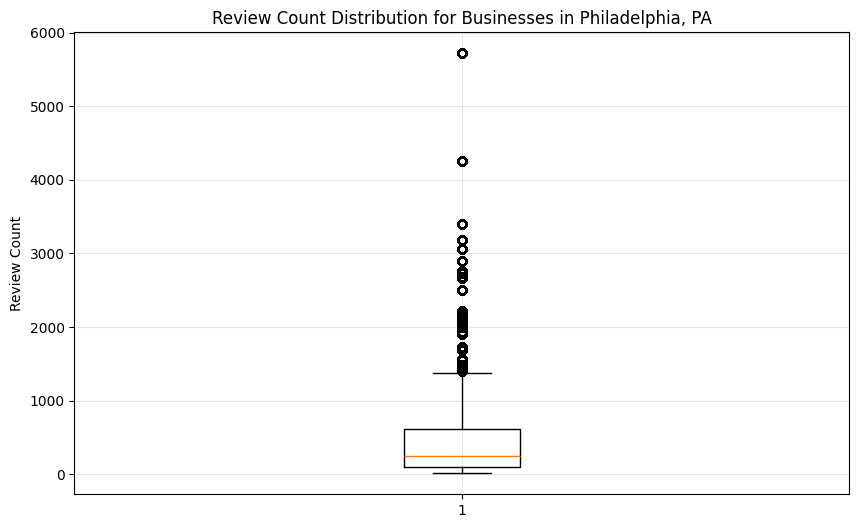

In [45]:
plt.figure(figsize=(10, 6))
plt.boxplot(reviews_enriched['business_review_count'], vert=True)
plt.ylabel('Review Count')
plt.title('Review Count Distribution for Businesses in Philadelphia, PA')
plt.grid(alpha=0.3)
plt.show()

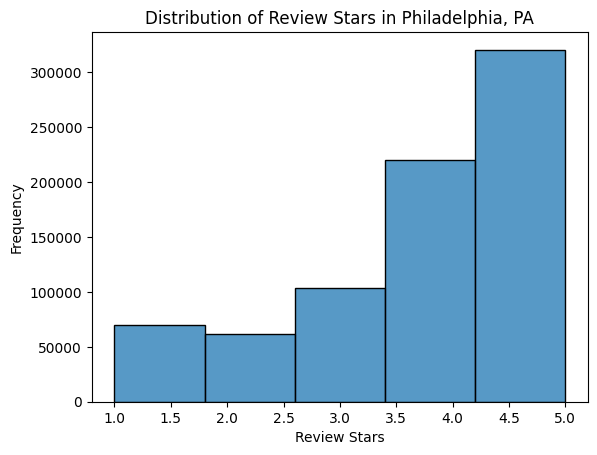

In [ ]:
#lests see if reviews_enriched['review_stars'] presents J curve:
#but since its a joined table, businesses 
sns.histplot(reviews_enriched['review_stars'], bins=5, kde=False)
plt.xlabel('Review Stars')
plt.ylabel('Frequency')
plt.title('Distribution of Review Stars in Philadelphia, PA')
plt.show()

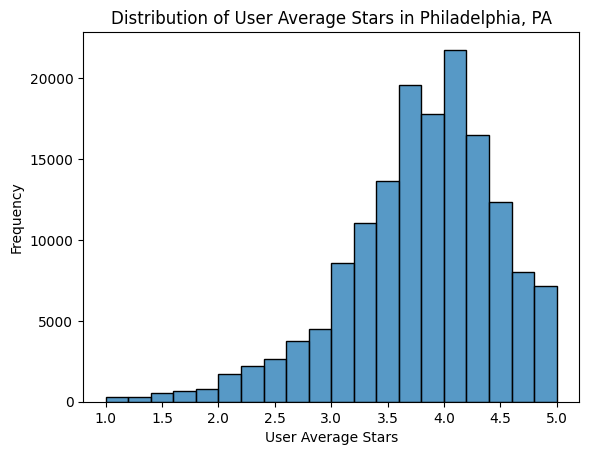

In [51]:
#reviews_enriched['user_average_stars'] distribution
sns.histplot(
    reviews_enriched.drop_duplicates(subset=['user_id'])['user_average_stars'], 
    bins=20, kde=False
)
plt.xlabel('User Average Stars')
plt.ylabel('Frequency')
plt.title('Distribution of User Average Stars in Philadelphia, PA')
plt.show()

In [40]:
#divide reviews_enriched_v1 parquet in smaller parquet files that git can handle, we will divide it in files of 100k rows each
num_rows = len(reviews_enriched)
rows_per_file = 100000
num_files = (num_rows // rows_per_file) + 1
print(f'Number of rows: {num_rows}, Rows per file: {rows_per_file}, Number of files: {num_files}')
for i in range(num_files):
    start_row = i * rows_per_file
    end_row = min((i + 1) * rows_per_file, num_rows)
    reviews_enriched.iloc[start_row:end_row].to_parquet(rf'data\processed\reviews_enriched_v1_part_{i+1}.parquet', index=False, engine='pyarrow')

Number of rows: 775955, Rows per file: 100000, Number of files: 8


In [41]:
#unite all the parts of reviews_enriched_v1 into a single dataframe
reviews_enriched_parts = []
for i in range(num_files):
    part = pd.read_parquet(rf'data\processed\reviews_enriched_v1_part_{i+1}.parquet', engine='pyarrow')
    reviews_enriched_parts.append(part)
reviews_enriched = pd.concat(reviews_enriched_parts, ignore_index=True)
reviews_enriched.to_parquet(r'data\processed\reviews_enriched_v1.parquet', index=False, engine='pyarrow')

In [66]:
reviews_enriched=pd.read_parquet(r'data\processed\reviews_enriched_v1.parquet', engine='pyarrow')
print(f'Number of rows in the enriched reviews dataset: {len(reviews_enriched)}')

Number of rows in the enriched reviews dataset: 775955
